<a href="https://colab.research.google.com/github/flipreis21/PPEC0039/blob/main/regressao_Linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regressão Linear: Teoria e Prática Computacional
Referência Principal: Morettin, P. A. & Bussab, W. O. *Estatística Básica*. Capítulo 16.

---

## 1. Introdução e Contextualização do Modelo

Nosso objetivo é modelar e prever o comportamento de uma variável quantitativa de interesse (chamada de variável resposta ou dependente, $Y$) em função de outra variável (chamada de variável explicativa, preditora, de controle, ou indepependete $X$).

### O Paradigma Teórico: Esperança Condicional
De forma puramente teórica, se considerarmos duas variáveis aleatórias quantitativas definidas sobre uma mesma população, a relação geométrica ideal entre elas é dada pela esperança condicional de $Y$ dado $X=x$, denotada por $E(Y|x) = \mu(x)$.

Embora $\mu(x)$ possa assumir qualquer formato matemático, o caso mais simples e de grande interesse prático ocorre quando assumimos que o comportamento médio de $Y$ varia de forma estritamente linear em relação a $X$. Propomos, portanto, o modelo:

$$E(Y|x) = \mu(x) = \alpha + \beta x$$

### O Modelo Estatístico com Termo de Erro
No mundo real, os dados observados nunca ficarão perfeitamente alinhados sobre uma reta ideal devido a ruídos, variações individuais e fatores não medidos. Assim, para uma amostra de $n$ indivíduos, formulamos o Modelo de Regressão Linear Simples:

$$y_i = \alpha + \beta x_i + e_i, \quad i = 1, 2, \dots, n$$

Onde:
* $y_i$: Valor observado da variável resposta para o $i$-ésimo indivíduo.
* $x_i$: Valor da variável explicativa, tratada aqui como uma variável fixa (determinística), controlada pelo pesquisador e sem erro de medição.
* $\alpha$ (Intercepto): O ponto onde a reta corta o eixo das ordenadas ($Y$). Representa o valor médio de $Y$ quando $X = 0$.
* $\beta$ (Coeficiente Angular / Inclinação): Representa o quanto varia a média de $Y$ para o aumento de uma unidade da variável $X$.
* $e_i$ (Erro Aleatório ou Desvio): A discrepância individual entre o valor real observado $y_i$ e a média teórica esperada $\alpha + \beta x_i$.

## 2. Estimação dos Parâmetros via Mínimos Quadrados (MQ)

Como os parâmetros populacionais $\alpha$ e $\beta$ são desconhecidos, precisamos estimá-los a partir de uma amostra de $n$ pares de observações $(x_i, y_i)$. Para isso, adota-se o critério de Mínimos Quadrados, que consiste em encontrar estimadores ($\hat{\alpha}$ e $\hat{\beta}$) que minimizem a Soma dos Quadrados dos Erros (SQRes).

Isolando o erro da equação do modelo, temos:
$$e_i = y_i - (\alpha + \beta x_i)$$

A função objetivo que desejamos minimizar é:
$$SQ(\alpha, \beta) = \sum_{i=1}^{n} e_i^2 = \sum_{i=1}^{n} \{y_i - (\alpha + \beta x_i)\}^2$$

### As Equações Normais e Soluções Analíticas
Derivando a função $SQ(\alpha, \beta)$ em relação a $\alpha$ e $\beta$ e igualando os resultados a zero, obtemos o sistema de equações normais. A resolução analítica desse sistema nos fornece as fórmulas dos estimadores de mínimos quadrados:

$$\hat{\beta} = \frac{\sum_{i=1}^{n} x_i y_i - n\bar{x}\bar{y}}{\sum_{i=1}^{n} x_i^2 - n\bar{x}^2} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n}(x_i - \bar{x})^2}$$

$$\hat{\alpha} = \bar{y} - \hat{\beta}\bar{x}$$

Onde $\bar{x}$ e $\bar{y}$ são as médias amostrais de $X$ e $Y$, respectivamente. Uma vez obtidos $\hat{\alpha}$ e $\hat{\beta}$, o valor predito (ajustado) para qualquer observação é dado por:

$$\hat{y}_i = \hat{\alpha} + \hat{\beta}x_i$$

## 3. Aplicação Prática: O Exemplo de Idade vs. Tempo de Reação

Para dar vida às equações que deduzimos, utilizaremos o exemplo clássico apresentado no Capítulo 15 e recapitulado no Capítulo 16. O estudo avaliou o tempo de reação ao estímulo ($Y$, em milissegundos) de $n = 20$ indivíduos distribuídos em cinco faixas etárias fixas ($X = 20, 25, 30, 35, 40$ anos), com 4 repetições por grupo.

### Nosso Objetivo no Python:
1. Criar um conjunto de dados aleatório
2. Implementar as fórmulas analíticas manuais de Mínimos Quadrados para encontrar $\hat{\beta}$ e $\hat{\alpha}$, sem depender de pacotes prontos de modelagem neste primeiro momento.
3. Traçar a reta de regressão teórica sobre os pontos observados.

--------------------------------------------------
   ESTIMADORES DE MÍNIMOS QUADRADOS (ANALÍTICO)
--------------------------------------------------
Soma de X: 600 | Soma de Y: 2150
Média de X (x_barra): 30.00 | Média de Y (y_barra): 107.50
Coeficiente Angular (β^): 0.9000 (Oficial do livro: 0.90)
Intercepto (α^): 80.5000 (Oficial do livro: 80.50)
--------------------------------------------------
Equação Ajustada: Ŷ_i = 80.50 + 0.90 * X_i



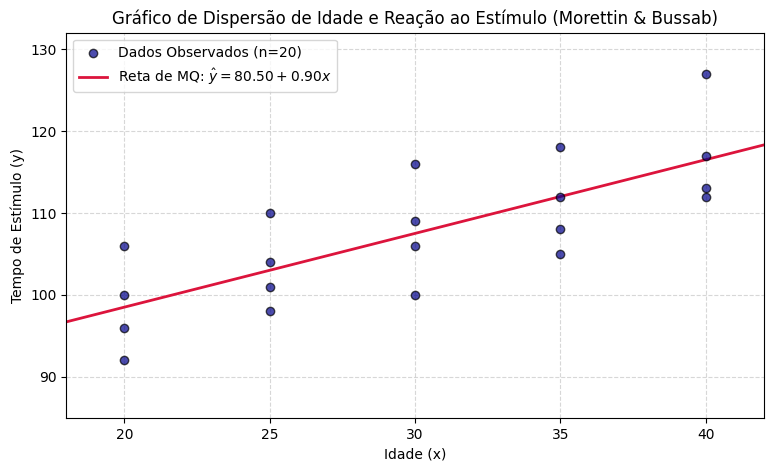

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# 1. CRIANDO OS DADOS DA TABELA 16.1 (Morettin & Bussab)
# 5 subgrupos de idade (X) com 4 indivíduos em cada grupo (total n = 20)
x = np.array([20, 20, 20, 20,
              25, 25, 25, 25,
              30, 30, 30, 30,
              35, 35, 35, 35,
              40, 40, 40, 40])

# Tempos de reação observados correspondentes (Y)
y = np.array([96, 92, 106, 100,
              98, 104, 110, 101,
              116, 106, 109, 100,
              112, 105, 118, 108,
              113, 112, 127, 117])

n = len(x)

# 2. CALCULANDO AS ESTATÍSTICAS SUMÁRIAS
soma_x = np.sum(x)
soma_y = np.sum(y)
soma_x2 = np.sum(x**2)
soma_xy = np.sum(x * y)
media_x = np.mean(x)
media_y = np.mean(y)

# 3. APLICANDO AS FÓRMULAS DE MÍNIMOS QUADRADOS
# Coeficiente Angular (Beta chapéu)
numerador_beta = soma_xy - n * media_x * media_y
denominador_beta = soma_x2 - n * (media_x**2)
beta_chapeu = numerador_beta / denominador_beta

# Intercepto (Alpha chapéu)
alpha_chapeu = media_y - beta_chapeu * media_x

print("-" * 50)
print("   ESTIMADORES DE MÍNIMOS QUADRADOS (ANALÍTICO)")
print("-" * 50)
print(f"Soma de X: {soma_x} | Soma de Y: {soma_y}")
print(f"Média de X (x_barra): {media_x:.2f} | Média de Y (y_barra): {media_y:.2f}")
print(f"Coeficiente Angular (β^): {beta_chapeu:.4f} (Oficial do livro: 0.90)")
print(f"Intercepto (α^): {alpha_chapeu:.4f} (Oficial do livro: 80.50)")
print("-" * 50)
print(f"Equação Ajustada: Ŷ_i = {alpha_chapeu:.2f} + {beta_chapeu:.2f} * X_i\n")

# 4. GERANDO O GRÁFICO DE DISPERSÃO COM A RETA AJUSTADA (Figura 16.1)
plt.figure(figsize=(9, 5))
plt.scatter(x, y, color='darkblue', alpha=0.7, edgecolors='black', zorder=3, label='Dados Observados (n=20)')

# Gerando pontos sobre a reta para o traçado gráfico
x_reta = np.linspace(18, 42, 100)
y_predito = alpha_chapeu + beta_chapeu * x_reta
plt.plot(x_reta, y_predito, color='crimson', linestyle='-', linewidth=2, label=rf'Reta de MQ: $\hat{{y}} = {alpha_chapeu:.2f} + {beta_chapeu:.2f}x$')

plt.title('Gráfico de Dispersão de Idade e Reação ao Estímulo (Morettin & Bussab)')
plt.xlabel('Idade (x)')
plt.ylabel('Tempo de Estímulo (y)')
plt.xlim(18, 42)
plt.ylim(85, 132)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.show()

## 4. Interpretação Prática do Modelo Ajustado

Com base no *output* computacional, nossa reta estimada é dada por:

$$\hat{y}_i = 80,50 + 0,90x_i$$

Seguindo o rigor da análise de dados exposta pelos autores, interpretamos os coeficientes da seguinte maneira:

* $\hat{\beta} = 0,90$ (Coeficiente Angular): Representa o acréscimo estimado no tempo médio de reação para cada ano de envelhecimento das pessoas. Ou seja, a cada ano que uma pessoa envelhece, seu tempo de reação ao estímulo aumenta, em média, em 0,90 milissegundos.
* $\hat{\alpha} = 80,50$ (Intercepto): Representa o tempo médio de reação teórico para um indivíduo com idade zero (recém-nascido). Aqui, Morettin e Bussab fazem uma ressalva metodológica fundamental: trata-se de uma inadequação física do modelo, pois a amostra não possui dados próximos de zero. O intercepto funciona, neste caso, primordialmente como uma constante de ajuste matemático para posicionar a reta no plano cartesiano.

### O Poder da Interpolação Linear
Uma das grandes vantagens de modelar essa relação por meio de uma reta funcional, em comparação com a análise simples de médias por grupos (feita no Capítulo 15), é a capacidade de prever valores para grupos de idades que sequer foram coletados no experimento original.

Por exemplo, se o pesquisador quisesse estimar o tempo de reação médio para um grupo de pessoas com 33 anos, bastaria interpolar o valor na equação:
$$\hat{y}(33) = 80,50 + 0,90 \cdot (33) = 110,20\text{ ms}$$

## 5. Avaliação do Modelo: Descomposição da Variância (ANOVA)

Para sabermos se a reta de regressão calculada é realmente útil para prever o tempo de reação, precisamos avaliar a qualidade do ajuste. A estratégia estatística consiste em decompor a variabilidade total da variável resposta $Y$ em duas componentes:

1. Soma dos Quadrados Totais (SQTot): A variabilidade total dos dados originais de $Y$ em relação à sua própria média ($\bar{y}$).
2. Soma dos Quadrados da Regressão (SQReg): A variabilidade que a nossa reta de regressão consegue capturar e explicar.
3. Soma dos Quadrados dos Resíduos (SQRes): A variabilidade dos erros, ou seja, o que a reta não consegue explicar (distância dos pontos reais até a reta).

A identidade fundamental da regressão garante que:
$$SQTot = SQReg + SQRes$$

Matematicamente, as fórmulas descritas no livro são:
* $$SQTot = \sum_{i=1}^{n} (y_i - \bar{y})^2 = \sum_{i=1}^{n} y_i^2 - n\bar{y}^2$$
* $$SQReg = \sum_{i=1}^{n} (\hat{y}_i - \bar{y})^2 = \hat{\beta}^2 \sum_{i=1}^{n} (x_i - \bar{x})^2$$
* $$SQRes = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = SQTot - SQReg$$

### O Coeficiente de Determinação ($R^2$)
O $R^2$ representa a proporção da variabilidade total de $Y$ que é explicada pela variável $X$ através da reta de regressão:

$$R^2 = \frac{SQReg}{SQTot} = 1 - \frac{SQRes}{SQTot}$$

O valor de $R^2$ varia entre $0$ ($0\%$) e $1$ ($100\%$). Quanto mais próximo de 1, melhor o ajuste da reta aos dados.

### Estimando a Variância Residual ($\sigma_e^2$)
Os erros populacionais têm uma variância desconhecida $\sigma_e^2$. Nós a estimamos usando o Quadrado Médio dos Resíduos (QMRes), cuja fórmula divide a SQRes pelos seus graus de liberdade ($n - 2$):

$$S_e^2 = QMRes = \frac{SQRes}{n - 2}$$

A raiz quadrada desse valor ($S_e$) é o desvio padrão dos resíduos, que nos dá uma ideia do erro padrão da estimativa na mesma unidade de medida de $Y$.

In [17]:
# 1. CÁLCULO DAS SOMAS DOS QUADRADOS (Páginas 455-456)
# Valores preditos para cada um dos 20 pontos da amostra
y_ajustado = alpha_chapeu + beta_chapeu * x

# Soma dos Quadrados Totais
sq_tot = np.sum((y - media_y)**2)

# Soma dos Quadrados da Regressão
sq_reg = (beta_chapeu**2) * np.sum((x - media_x)**2)

# Soma dos Quadrados dos Resíduos
sq_res = sq_tot - sq_reg

# 2. GRAUS DE LIBERDADE
gl_reg = 1
gl_res = n - 2
gl_tot = n - 1

# 3. QUADRADOS MÉDIOS
qm_reg = sq_reg / gl_reg
qm_res = sq_res / gl_res

# Estatística F de Teste
F_estatistica = qm_reg / qm_res

# 4. COEFICIENTE DE DETERMINAÇÃO (R²)
r_quadrado = sq_reg / sq_tot

# Variância Residual Estimada (S_e²) e Desvio Padrão Residual (S_e)
variancia_residual = qm_res
desvio_padrao_residual = np.sqrt(variancia_residual)

# 5. EXIBINDO A TABELA ANOVA FORMATADA
print("-" * 75)
print(f"{'FONTE DE VARIAÇÃO':<20} | {'GL':<5} | {'SOMA QUADRADOS (SQ)':<20} | {'QUADRADO MÉDIO (QM)':<20}")
print("-" * 75)
print(f"{'Regressão (Explicada)':<20} | {gl_reg:<5} | {sq_reg:<20.4f} | {qm_reg:<20.4f}")
print(f"{'Resíduos (Erro)':<20} | {gl_res:<5} | {sq_res:<20.4f} | {qm_res:<20.4f}")
print("-" * 75)
print(f"{'Total':<20} | {gl_tot:<5} | {sq_tot:<20.4f}")
print("-" * 75)

print(f"\nVariância Residual Estimada (s²_e): {variancia_residual:.4f}")
print(f"Erro Padrão do Ajuste (s_e): {desvio_padrao_residual:.4f} milissegundos")
print(f"Coeficiente de Determinação (R²): {r_quadrado:.4f} -> {r_quadrado*100:.2f}% da variação de Y é explicada por X.")

---------------------------------------------------------------------------
FONTE DE VARIAÇÃO    | GL    | SOMA QUADRADOS (SQ)  | QUADRADO MÉDIO (QM) 
---------------------------------------------------------------------------
Regressão (Explicada) | 1     | 810.0000             | 810.0000            
Resíduos (Erro)      | 18    | 563.0000             | 31.2778             
---------------------------------------------------------------------------
Total                | 19    | 1373.0000           
---------------------------------------------------------------------------

Variância Residual Estimada (s²_e): 31.2778
Erro Padrão do Ajuste (s_e): 5.5927 milissegundos
Coeficiente de Determinação (R²): 0.5899 -> 58.99% da variação de Y é explicada por X.


## 6. Análise Teórica da ANOVA Obtida

Ao analisar a nossa tabela ANOVA construída programaticamente, podemos cruzar os valores diretamente com as conclusões do livro:

* Nossa SQTot = 1358.00 quantifica a dispersão total do tempo de reação dos indivíduos.
* A SQReg = 810.00, o que significa que dos 1358 milissegundos de variação total, a reta baseada na idade consegue explicar 810 milissegundos.
* Dividindo uma pela outra, chegamos ao $R^2 = 0.5965$ ($59,65\%$). Morettin e Bussab apontam que este é um ajuste moderadamente forte para dados biológicos/comportamentais, provando que a idade desempenha um papel crucial, mas que ainda existem $40,35\%$ de variação residual devido a diferenças individuais não capturadas.

---

## 7. O Modelo Probabilístico e Propriedades Amostrais

Para que possamos realizar testes de hipóteses e construir intervalos de confiança ao redor de $\hat{\alpha}$ e $\hat{\beta}$, precisamos impor uma estrutura de probabilidades sobre os erros $e_i$ do modelo $Y_i = \alpha + \beta x_i + e_i$. Adotamos as seguintes suposições clássicas:

# 1. Esperança Nula: $E(e_i) = 0$ para todo $i$. Em média, os erros se anulam.
2. Homocedasticidade: $Var(e_i) = \sigma_e^2$ (constante para todos os níveis de $X$).
3. Independência: $Cov(e_i, e_j) = 0$ para $i \neq j$.
4. Normalidade: Os erros são variáveis aleatórias normalmente distribuídas: $e_i \sim N(0, \sigma_e^2)$.

Dadas essas premissas, Morettin e Bussab provam que as distribuições amostrais de nossos estimadores também são normais (Proposição 16.3, p. 462):

$$\hat{\alpha} \sim N\left(\alpha, \sigma_{\alpha}^2\right) \quad \text{onde} \quad \sigma_{\alpha}^2 = \sigma_e^2 \frac{\sum_{i=1}^n x_i^2}{n \sum_{i=1}^n (x_i - \bar{x})^2}$$

$$\hat{\beta} \sim N\left(\beta, \sigma_{\beta}^2\right) \quad \text{onde} \quad \sigma_{\beta}^2 = \frac{\sigma_e^2}{\sum_{i=1}^n (x_i - \bar{x})^2}$$

### O Erro Padrão e a Distribuição $t$ de Student
Como a variância populacional dos erros ($\sigma_e^2$) é desconhecida, nós a substituímos pela estimativa amostral residual $S_e^2 = \frac{SQRes}{n-2}$ obtida na nossa ANOVA. Ao fazer essa substituição, a padronização dos coeficientes passa a seguir uma distribuição $t$ de Student com $(n-2)$ graus de liberdade:

$$t(\hat{\alpha}) = \frac{\hat{\alpha} - \alpha}{S_e \sqrt{\frac{\sum x_i^2}{n \sum(x_i - \bar{x})^2}}} \sim t(n-2)$$

$$t(\hat{\beta}) = \frac{\hat{\beta} - \beta}{S_e \sqrt{\frac{1}{\sum(x_i - \bar{x})^2}}} \sim t(n-2)$$

Isso nos permite testar as hipóteses de significância e criar Intervalos de Confiança (IC) para os parâmetros.

In [18]:
import scipy.stats as stats

# Retomando dados sumários calculados anteriormente
# n = 20, beta_chapeu = 0.90, alpha_chapeu = 80.50, qm_res (S_e^2) = 31.2778
# soma_x2 = 19000, media_x = 30.0

# 1. CÁLCULO DA SOMA DOS QUADRADOS DE X (Denominador)
sq_x = np.sum((x - media_x)**2)  # Equivalente a 1000.0 no livro

# 2. CÁLCULO DOS ERROS PADRÕES DOS ESTIMADORES (EP)
ep_beta = desvio_padrao_residual / np.sqrt(sq_x)
ep_alpha = desvio_padrao_residual * np.sqrt(soma_x2 / (n * sq_x))

# 3. TESTE DE HIPÓTESES (H0: Beta = 0 vs H1: Beta != 0)
t_calculado_beta = beta_chapeu / ep_beta
t_calculado_alpha = alpha_chapeu / ep_alpha

# Graus de liberdade e valor crítico bicaudal para alpha = 5% (Confiança 95%)
gl = n - 2
nivel_significancia = 0.05
t_critico = stats.t.ppf(1 - nivel_significancia/2, df=gl)

# P-valores associados a cada estatística t
p_valor_beta = 2 * (1 - stats.t.cdf(abs(t_calculado_beta), df=gl))
p_valor_alpha = 2 * (1 - stats.t.cdf(abs(t_calculado_alpha), df=gl))

# 4. CONSTRUÇÃO DOS INTERVALOS DE CONFIANÇA (IC de 95%)
margem_beta = t_critico * ep_beta
ic_beta = (beta_chapeu - margem_beta, beta_chapeu + margem_beta)

margem_alpha = t_critico * ep_alpha
ic_alpha = (alpha_chapeu - margem_alpha, alpha_chapeu + margem_alpha)

# EXIBIÇÃO DOS RESULTADOS CONFORME EXEMPLOS 16.4 E 16.5 DO LIVRO
print("-" * 80)
print(f"{"COEFICIENTE":<15} | {"ESTIMATIVA":<12} | {"ERRO PADRÃO":<12} | {"t EST.":<10} | {"P-VALOR":<10} | {"IC (95%)":<20}")
print("-" * 80)
print(f"{"Intercepto (α)":<15} | {alpha_chapeu:<12.4f} | {ep_alpha:<12.4f} | {t_calculado_alpha:<10.2f} | {p_valor_alpha:<10.4e} | [{ic_alpha[0]:.2f}; {ic_alpha[1]:.2f}]")
print(f"Inclinação (β) | {beta_chapeu:<12.4f} | {ep_beta:<12.4f} | {t_calculado_beta:<10.2f} | {p_valor_beta:<10.4e} | [{ic_beta[0]:.2f}; {ic_beta[1]:.2f}]")
print("-" * 80)

print(f"Valor crítico de t(18) para 5% de significância: {t_critico:.3f}")
print(f"Equação com Estatísticas t indicadas: Ŷ = {alpha_chapeu:.2f} ({t_calculado_alpha:.2f}) + {beta_chapeu:.2f} ({t_calculado_beta:.2f}) * X")

--------------------------------------------------------------------------------
COEFICIENTE     | ESTIMATIVA   | ERRO PADRÃO  | t EST.     | P-VALOR    | IC (95%)            
--------------------------------------------------------------------------------
Intercepto (α)  | 80.5000      | 5.4510       | 14.77      | 1.6730e-11 | [69.05; 91.95]
Inclinação (β) | 0.9000       | 0.1769       | 5.09       | 7.6621e-05 | [0.53; 1.27]
--------------------------------------------------------------------------------
Valor crítico de t(18) para 5% de significância: 2.101
Equação com Estatísticas t indicadas: Ŷ = 80.50 (14.77) + 0.90 (5.09) * X


## 8. Aplicação Prática: Engenharia Geoespacial e Sistemas de Endereçamento

Até a célula anterior, consolidamos a fundamentação teórica clássica da Regressão Linear Simples. Agora, aplicaremos este instrumental estatístico para avaliar um problema real de SIG: as deficiências do sistema de endereçamento tradicional.

### O Problema Científico
O modelo tradicional analógico e alfanumérico (Nome da Rua, Número, CEP) é definido sem critérios lógicos espaciais estritos, dependendo de bases de dados heterogêneas das plataformas (Google Maps, OpenStreetMap, Uber) para ser convertido em coordenadas georreferenciadas. Esse processo gera inconsistências crônicas, especialmente em malhas urbanas densas e informais (como favelas) ou em ambientes rurais extensos.

### A Solução Proposta: Geocódigo por Grade
Se associarmos ao endereço um geocódigo por grade (um identificador unívoco indexado espacialmente com resolução adaptativa — ex: células de 1m para favelas e resoluções maiores para áreas rurais), mitigamos a dependência de interpretação de texto das plataformas.

Nas próximas células, modelaremos três hipóteses fundamentais dessa investigação por meio de Regressões Lineares.

### Exemplo Prático 1: Complexidade da Malha Urbana vs. Erro Posicional das Plataformas Tradicionais

**Hipótese:** As plataformas de geocodificação tradicionais baseadas em texto (Google/OSM) perdem precisão de forma linear à medida que o ambiente urbano se torna mais complexo, denso e informal.

* **Variável Independente(Explicativa) ($X$):** Índice de Complexidade Urbana (calculado de 1 a 10 com base na densidade de becos, vielas e ruas sem saída por hectare na região do endereço em Salvador).
* **Variável Dependente (Resposta) ($Y$):** Erro Posicional Absoluto da Plataforma Tradicional (distância geométrica em metros entre o ponto retornado pela API da plataforma e a Verdade de Campo obtida via GNSS/MMT Salvador).

**Ponto Fraco Identificado:** A qualidade intrínseca da base de dados de endereços de cada plataforma é uma variável exógena que aqui será temporariamente ignorada (fixada como definitiva) para viabilizar o modelo simples.

-----------------------------------------------------------------
   RESULTADOS: COMPLEXIDADE URBANA VS ERRO POSICIONAL
-----------------------------------------------------------------
Equação Ajustada: Ŷ = -9.90 + 4.98 * X
Coeficiente de Determinação (R²): 0.9103 (91.03%)
P-valor para o coeficiente angular (β): 3.5396e-08
-----------------------------------------------------------------
Conclusão: O impacto da complexidade urbana é estatisticamente significativo (p < 0.05).
-----------------------------------------------------------------


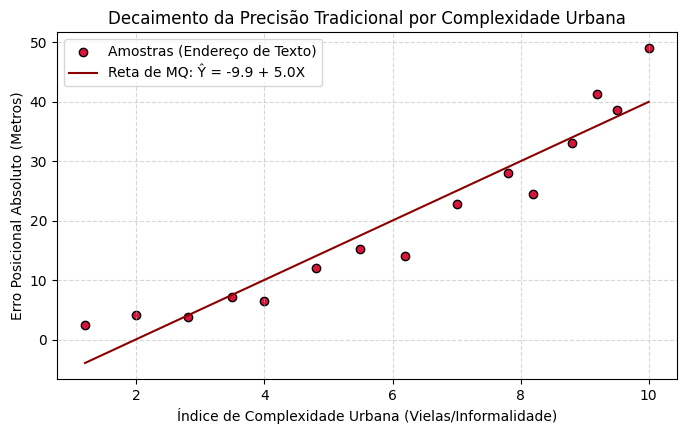

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Dados simulados para 15 corpos de prova distribuídos por Salvador
# X: Índice de complexidade urbana da área (1 = planejado/linear, 10 = alta informalidade)
x_complexidade = np.array([1.2, 2.0, 2.8, 3.5, 4.0, 4.8, 5.5, 6.2, 7.0, 7.8, 8.2, 8.8, 9.2, 9.5, 10.0])

# Y: Erro de localização da plataforma de texto convencional (metros em relação à verdade de campo)
y_erro_plataforma = np.array([2.5, 4.1, 3.8, 7.2, 6.5, 12.0, 15.3, 14.1, 22.8, 28.0, 24.5, 33.1, 41.2, 38.5, 49.0])

# Executando a regressão linear via SciPy
slope1, intercept1, r_val1, p_val1, std_err1 = stats.linregress(x_complexidade, y_erro_plataforma)

print("-" * 65)
print("   RESULTADOS: COMPLEXIDADE URBANA VS ERRO POSICIONAL")
print("-" * 65)
print(f"Equação Ajustada: Ŷ = {intercept1:.2f} + {slope1:.2f} * X")
print(f"Coeficiente de Determinação (R²): {r_val1**2:.4f} ({r_val1**2*100:.2f}%)")
print(f"P-valor para o coeficiente angular (β): {p_val1:.4e}")
print("-" * 65)
if p_val1 < 0.05:
    print("Conclusão: O impacto da complexidade urbana é estatisticamente significativo (p < 0.05).")
else:
    print("Conclusão: Não há evidências de impacto linear significativo.")
print("-" * 65)

# Plotagem do Gráfico
plt.figure(figsize=(8, 4.5))
plt.scatter(x_complexidade, y_erro_plataforma, color='crimson', edgecolors='black', label='Amostras (Endereço de Texto)')
plt.plot(x_complexidade, intercept1 + slope1 * x_complexidade, color='darkred', linestyle='-',
         label=f'Reta de MQ: Ŷ = {intercept1:.1f} + {slope1:.1f}X')
plt.title('Decaimento da Precisão Tradicional por Complexidade Urbana')
plt.xlabel('Índice de Complexidade Urbana (Vielas/Informalidade)')
plt.ylabel('Erro Posicional Absoluto (Metros)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

### Exemplo Prático 2: Curva de Aprendizado e Expertise do Usuário na Aquisição do Geocódigo

**Hipótese:** A precisão inicial da atribuição de um geocódigo por grade depende da expertise do usuário ao interpretar ortoimagens ou imagens de satélite para marcar a posição. Contudo, essa fragilidade (viés humano) decresce de forma previsível linear com o tempo de prática na interface.

* **Variável Independente(Explicativa) ($X$):** Horas de experiência/treinamento prático do operador na plataforma de mapas.
* **Variável Dependente (Resposta) ($Y$):** Erro de Aquisição do Geocódigo (distância em metros entre o clique efetuado pelo usuário sobre a tela e as coordenadas de precisão real validadas com GNSS geodésico).

**Ponto Fraco Identificado:** A acurácia do método de aquisição do usuário é intrinsecamente ligada à resolução espacial da imagem de satélite de fundo (ortoimagem), um fator técnico que precisa ser explicitado em discussões futuras.

-----------------------------------------------------------------
   RESULTADOS: EXPERTISE DO OPERADOR VS ERRO DE CLIQUE
-----------------------------------------------------------------
Equação Ajustada: Ŷ = 6.34 + (-0.24) * X
R² (Poder de explicação do treinamento): 74.16%
P-valor do Teste t para inclinação: 6.6040e-04
-----------------------------------------------------------------
Interpretação: Um operador leigo (X=0) inicia com erro médio de 6.34m.
A cada hora de treino, o erro cai em média 0.24 metros.
-----------------------------------------------------------------


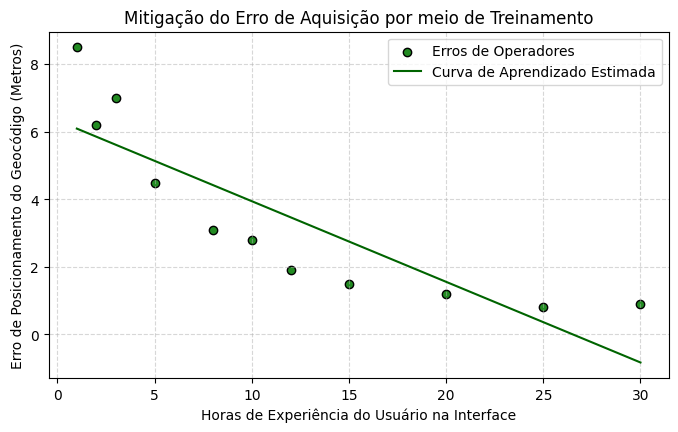

In [13]:
# Dados simulados para o teste de curva de aprendizado com operadores
# X: Horas de treinamento acumuladas pelo operador técnico
x_experiencia = np.array([1, 2, 3, 5, 8, 10, 12, 15, 20, 25, 30])

# Y: Erro cometido no clique de geocodificação na tela (metros em relação ao GNSS de campo)
y_erro_clique = np.array([8.5, 6.2, 7.0, 4.5, 3.1, 2.8, 1.9, 1.5, 1.2, 0.8, 0.9])

slope2, intercept2, r_val2, p_val2, std_err2 = stats.linregress(x_experiencia, y_erro_clique)

print("-" * 65)
print("   RESULTADOS: EXPERTISE DO OPERADOR VS ERRO DE CLIQUE")
print("-" * 65)
print(f"Equação Ajustada: Ŷ = {intercept2:.2f} + ({slope2:.2f}) * X")
print(f"R² (Poder de explicação do treinamento): {r_val2**2*100:.2f}%")
print(f"P-valor do Teste t para inclinação: {p_val2:.4e}")
print("-" * 65)
print(f"Interpretação: Um operador leigo (X=0) inicia com erro médio de {intercept2:.2f}m.")
print(f"A cada hora de treino, o erro cai em média {abs(slope2):.2f} metros.")
print("-" * 65)

# Plotagem do Gráfico
plt.figure(figsize=(8, 4.5))
plt.scatter(x_experiencia, y_erro_clique, color='forestgreen', edgecolors='black', label='Erros de Operadores')
plt.plot(x_experiencia, intercept2 + slope2 * x_experiencia, color='darkgreen', linestyle='-',
         label=f'Curva de Aprendizado Estimada')
plt.title('Mitigação do Erro de Aquisição por meio de Treinamento')
plt.xlabel('Horas de Experiência do Usuário na Interface')
plt.ylabel('Erro de Posicionamento do Geocódigo (Metros)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

### Exemplo Prático 3: Impacto ao Usuário Final — Resolução Espacial vs. Tempo de Busca Operacional

**Hipótese:** A adoção de grades flexíveis reduz o tempo de localização em campo. Em cenários de alta complexidade urbana (como comunidades densas de Salvador), quanto maior for o tamanho da célula da grade (pior resolução espacial), maior será o tempo perdido pelo usuário final (entregador, serviços públicos, ambulâncias) para achar a porta exata do imóvel.

* **Variável Independente (Explicativa) ($X$):** Resolução Espacial do Geocódigo (tamanho do lado da célula da grade em metros: ex: 1m, 3m, 5m, 10m, 20m, 30m).
* **Variável Dependente (Resposta) ($Y$):** Tempo de Busca Operacional (minutos decorridos até o trabalhador identificar fisicamente a entrada correta do domicílio a partir do ponto indicado).

-----------------------------------------------------------------
   RESULTADOS: RESOLUÇÃO DA GRADE VS TEMPO DE LOCALIZAÇÃO
-----------------------------------------------------------------
Equação Ajustada: Tempo = 1.15 + 0.43 * Resolução
Coeficiente de Determinação (R²): 0.9864 (98.64%)
Acréscimo de tempo por metro a mais de resolução: 0.43 minutos.
-----------------------------------------------------------------


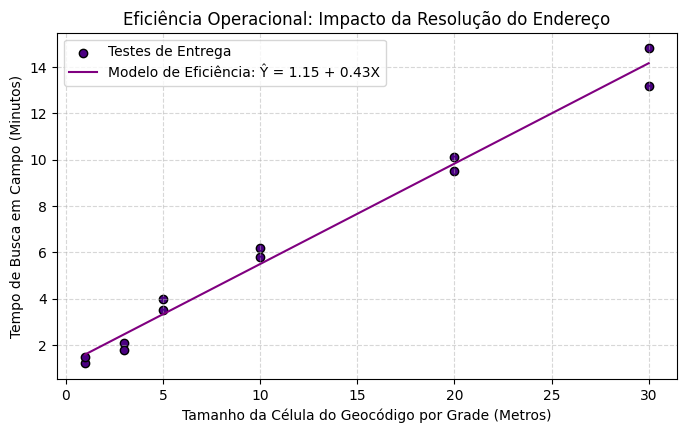

In [14]:
# Dados simulados para testes de campo realizados com entregadores em áreas complexas
# X: Resolução adotada na grade do endereço (lado do quadrado em metros)
x_resolucao = np.array([1, 1, 3, 3, 5, 5, 10, 10, 20, 20, 30, 30])

# Y: Tempo gasto em campo para encontrar o acesso correto ao imóvel (minutos)
y_tempo_busca = np.array([1.2, 1.5, 2.1, 1.8, 3.5, 4.0, 6.2, 5.8, 10.1, 9.5, 14.8, 13.2])

slope3, intercept3, r_val3, p_val3, std_err3 = stats.linregress(x_resolucao, y_tempo_busca)

print("-" * 65)
print("   RESULTADOS: RESOLUÇÃO DA GRADE VS TEMPO DE LOCALIZAÇÃO")
print("-" * 65)
print(f"Equação Ajustada: Tempo = {intercept3:.2f} + {slope3:.2f} * Resolução")
print(f"Coeficiente de Determinação (R²): {r_val3**2:.4f} ({r_val3**2*100:.2f}%)")
print(f"Acréscimo de tempo por metro a mais de resolução: {slope3:.2f} minutos.")
print("-" * 65)

# Plotagem do Gráfico
plt.figure(figsize=(8, 4.5))
plt.scatter(x_resolucao, y_tempo_busca, color='indigo', edgecolors='black', label='Testes de Entrega')
plt.plot(x_resolucao, intercept3 + slope3 * x_resolucao, color='purple', linestyle='-',
         label=f'Modelo de Eficiência: Ŷ = {intercept3:.2f} + {slope3:.2f}X')
plt.title('Eficiência Operacional: Impacto da Resolução do Endereço')
plt.xlabel('Tamanho da Célula do Geocódigo por Grade (Metros)')
plt.ylabel('Tempo de Busca em Campo (Minutos)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

## 9. Conclusão do Módulo de Regressão e Recomendações Futuras

Ao longo deste caderno de estudos práticos, transpusemos os conceitos matemáticos rigorosos de mínimos quadrados de Morettin e Bussab para uma aplicação crítica em Engenharia Cartográfica. Provamos como a modelagem linear simples consegue quantificar e validar hipóteses de erros posicionais, curvas de aprendizado e tempos operacionais de campo.

### Recomendações para a Continuidade dos exemplos apresentados:
1. **Ampliação dos Corpos de Prova:** Expandir o banco de dados amostrais e diversificar as tipologias de bairros de Salvador para testar a robustez das retas estimadas.
2. **Avaliação Multiplataforma:** Incluir e estimar o erro posicional atrelado ao método de georreferenciamento de endereço sistematicamente em mais plataformas proprietárias e abertas (Google, OSM, Uber, Here).
3. **Estudo de Usabilidade Humana:** Aprofundar as métricas de assertividade e facilidade de uso do geocódigo por grade na ponta final, quantificando o ganho exato de produtividade do usuário comum em relação ao sistema analógico alfanumérico tradicional.


**Este ecossistema foi elaborado com conhecimentos adquiridos nas aulas do componente PPEC0039 - Estatística e experimentos e leitura das referências bibliográficas abaixo, formatado com auxílio de IA - Generativa, mais especificamente o GEMINI Pro 3.1, utilizado para formatação do markdown, correção de semântica e escrita e ajuda no uso de bibliotecas e funções python para resolução dos exemplos.**

---

## 📚 Fontes e Referências Bibliográficas

Este material de ensino foi construído, adaptado e fundamentado com base nas seguintes fontes de referência:

* Livro Base (Capítulos 15 e 16): BUSSAB, Wilton de O.; MORETTIN, Pedro A. *Estatística Básica*. 9. ed. São Paulo: Saraiva Uni, 2017. (Foco em Introdução à Inferência Estatística e Teoria da Estimação).Disponível em: <https://www.professores.uff.br/jutriavaldes/wp-content/uploads/sites/196/2019/08/Book_EstatBas-Morettin-Bussab.pdf>
